In [92]:
#install sklearn on the spot
!pip install scikit-learn

In [93]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt

#DATA_FILEPATH_P2 = './dataset_clean_encoded_p2.csv'
DATA_FILEPATH_P2 = '../MAIN/dataset_clean_encoded_p2.csv'

data = pd.read_csv(DATA_FILEPATH_P2)
print("Verify shape of data after loading from csv, should have had 6 outlier rows removed from part 1:")
print(data.shape)

Verify shape of data after loading from csv, should have had 6 outlier rows removed from part 1:
(302, 15)


In [94]:
cat_cols = ['TSI','N2O','Aerosols']
cat_rows = ['Low','Medium','High']
cat_enums = ['L','M','H']
cat_rows_sort = ['2_High','0_Low','1_Medium']

TSI_freq = data['TSI'].value_counts().sort_values()
N2O_freq = data['N2O'].value_counts()
SOL_freq = data['Aerosols'].value_counts()

cat_freq = pd.concat([TSI_freq,N2O_freq,SOL_freq],axis=1).copy()
cat_freq.columns = cat_cols

# sorting the index without using methods
cat_freq.index = cat_rows_sort
cat_freq.sort_index(inplace=True)
cat_freq.index = cat_rows
print("Frequency of categorical values in each category:")
print()
print(cat_freq)

Frequency of categorical values in each category:

        TSI    N2O  Aerosols
Low      90  294.0       109
Medium  160    NaN       141
High     52    8.0        52


<span style="color:LightSkyBlue">

Next, we will visualise and annotate a graph to get a graphical understanding of the data:
</span>

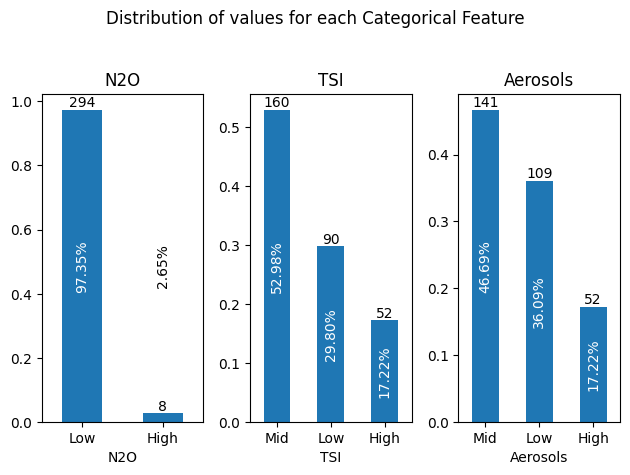

In [95]:
renaming_dict = {
    "H": "High",
    "M": "Mid",
    "L": "Low",
}

category_order = {'Low': 0, 'Mid': 1, 'High': 2}

categorical_features = data.dtypes[data.dtypes=="object"].index

n = len(categorical_features)
fig, ax = plt.subplots(1, n)

# plot for each catgorical variable
for i in range(n):
    feature = categorical_features[i]
    ax = plt.subplot(1,n,i+1)
    ax.set_title(feature)
    data[feature].value_counts(normalize=True).plot(kind='bar',rot=90)
    # Get the actual counts (not normalized)
    counts = data[feature].value_counts()
    # For each bar, add an annotation with the count
    for i, v in enumerate(counts):
        #print(i,v)
        ax.text(i, counts.values[i]/sum(counts.values), f"{v}", 
                ha='center', va='bottom')
        # Calculate percentage
        percentage = counts.values[i]/sum(counts.values) * 100
        if percentage > 5:  # Only show if > 5%
            ax.text(i, counts.values[i]/sum(counts.values) *0.5, f"{percentage:.2f}%", 
                    ha='center', va='center',rotation=90,c='white')
        else:
            mid = counts.mode()[1]
            ax.text(i, mid/sum(counts.values)*0.5, f"{percentage:.2f}%", 
                    ha='center', va='center',rotation=90,)
    
    current_labels = [label.get_text() for label in ax.get_xticklabels()]
    new_labels = [renaming_dict[label] for label in current_labels]
    ax.set_xticklabels(new_labels,rotation=0)

fig.suptitle('Distribution of values for each Categorical Feature')
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()


In [96]:
#Assessing mode per category
def calculate_mode_percentage(df):
    results = []
    for column in df.select_dtypes(include=['object', 'category']).columns:
        value_counts = df[column].value_counts(normalize=True)
        mode_value = value_counts.idxmax()
        percentage = value_counts.max() * 100
        results.append({
            'Variable': column,
            'Mode': mode_value,
            'Percentage': round(percentage, 2)
        })
    return pd.DataFrame(results)

modes_df = calculate_mode_percentage(data)

print("mode statistics:")
print(modes_df)

mode statistics:
   Variable Mode  Percentage
0       N2O    L       97.35
1       TSI    M       52.98
2  Aerosols    M       46.69


<span style="color:LightSkyBlue">

We observed that the data for the variable `N20` has a lack in variation (since 97.35% of the values all have the value 'L'). This means that it has low predictive power and will not contribute much to the model. As for the remaining two variables, despite having a relatively high dominant value contributing to 52.98% of the data, we have determined that it is still acceptable and thus will include it as a feature of our model.

In [97]:
exclude = ['N2O']

mask = datatypes.reindex(data.dtypes.index) == "object"
cat_features_selected = list(data.dtypes[mask].index)

# lazy filtering, removes N2O and other unwanted categorical variables, modifies references to encoded ones from part 1
cat_features_selected_u = list(i for i in cat_features_selected if i not in exclude) # use this to refer to raw categorical variable values
cat_features_selected = [str(i)+'_ord' for i in cat_features_selected if i not in exclude] # use this to refer to raw categorical variable values

print("Categorical features remaining:")
print(', '.join(cat_features_selected_u))

Categorical features remaining:
TSI, Aerosols


<span style="color:LightSkyBlue">

Now, we will visualising how `TSI` varies with `Aerosols` and vice versa:

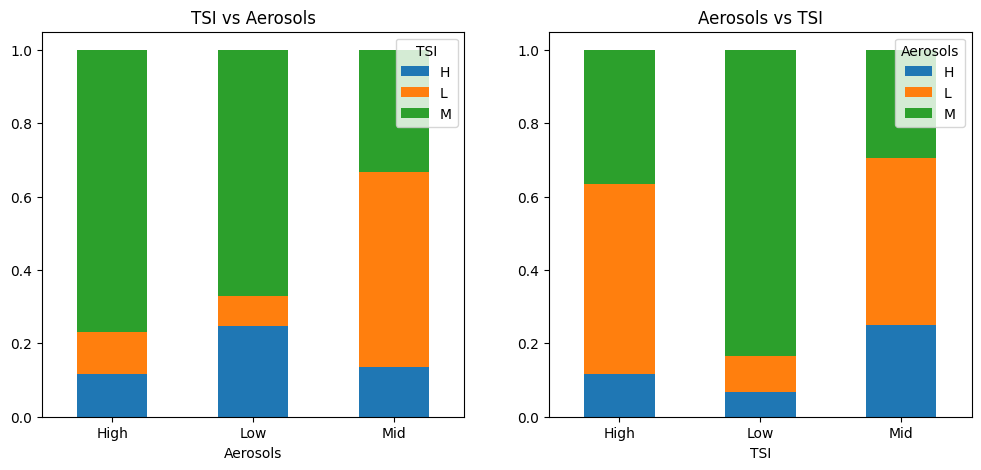

In [98]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot your crosstab on the first axes
pd.crosstab(data['Aerosols'], data["TSI"], normalize="index").plot.bar(
    stacked=True, 
    ax=ax1  # Specify the axes to plot on
)
ax1.set_title('Aerosols vs TSI')  # Add a title to the first plot

pd.crosstab(data['TSI'], data["Aerosols"], normalize="index").plot.bar(
    stacked=True, 
    ax=ax2  # Specify the axes to plot on
)

current_labels = [label.get_text() for label in ax1.get_xticklabels()]
new_labels = [renaming_dict[label] for label in current_labels]
ax1.set_xticklabels(new_labels,rotation=0)

current_labels = [label.get_text() for label in ax2.get_xticklabels()]
new_labels = [renaming_dict[label] for label in current_labels]
ax2.set_xticklabels(new_labels,rotation=0)

ax1.set_title('TSI vs Aerosols')  # Add a title to the first plot
ax2.set_title('Aerosols vs TSI')  # Add a title to the second plot
plt.show()

<span style="color:LightSkyBlue">

We can observe the following from a visualisation of the proportion of the each categorical variable relative to the other:
- For high and low levels of aerosols, the TSI seems to usually be medium. Relevant research indicates that this might be because `<FIND REASONS>`
- For medium Aerosol levels, the TSI level seems to usually be low. Relevant research indicates that this might be because `<FIND REASONS>`
- For instances with low levels of TSI, it seems that a majority of the associated instances seem to have medium aerosol levels, indicating that there might be a correlation between this specific level of solar irradiance that causes the composition of aerosols in the atmosphere to have a medium composition. Relevant research indicates that this might be because `<FIND REASONS>`

### TODO: fill up reasoning for observations on how Aerosol levels are distributed relative to TSI levels and vice versa. replace the `<FIND REASONS>` with meaningful research.
---

<span style="color:LightSkyBlue">

We can also look into how the response variable `Temp` is related to these variables.  To do that we plot a grouped boxplot and see the distribution of `Temp` across different categories for `Aerosols` and `TSI`:

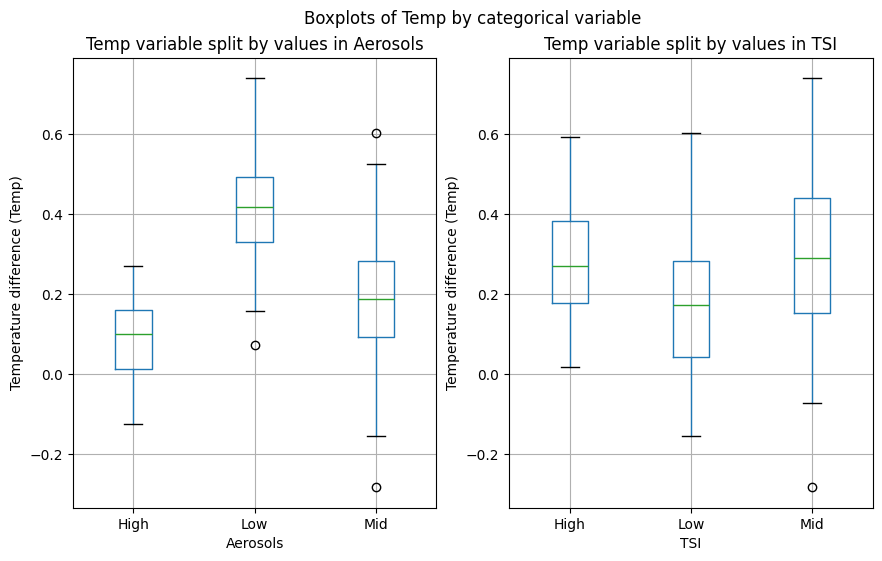

In [99]:
n = len(cat_features_selected_u)

r, c = 1,2
fig, ax = plt.subplots(r, c, figsize=(10,6))

for i in range(n):
    feature = cat_features_selected_u[::-1][i]
    ax = plt.subplot(r,c,i+1)
    data[[feature,'Temp']].boxplot(by=feature, ax=ax, rot=90)
    
    # format labels
    current_labels = [label.get_text() for label in ax.get_xticklabels()]
    new_labels = [renaming_dict[label] for label in current_labels]
    ax.set_xticklabels(new_labels,rotation=0)
    
    ax.set_ylabel("Temperature difference (Temp)")
    ax.set_xlabel(feature)
    ax.set_title(f"Temp variable split by values in {feature}")

fig.suptitle("Boxplots of Temp by categorical variable")

plt.show()

<span style="color:LightSkyBlue">

We can observe the following from a visualisation of how the values in the `Temp` variable is distributed over specific variables:

- Aerosols
    - Temperatures are generally higher for Low Aerosol levels, followed by Medium, then High levels. Relevant research indicates that this might be because `<FIND REASONS>`
    - The range of these temperatures is much smaller when aerosol levels are high, relative to the other aerosol levels. Relevant research indicates that this might be because `<FIND REASONS>`
- TSI
    - Temperatures are generally higher for medium TSI levels, followed by High and Low TSI levels. Relevant research indicates that this might be because `<FIND REASONS>`
    - The range of temperatures for High and Low TSI levels shares a similar median. Relevant research indicates that this might be because `<FIND REASONS>`
    - The range of temperatures is generally the same across all TSI levels. Relevant research indicates that this might be because `<FIND REASONS>`
- General observations
    - Each TSI level category seems to have a larger range of temperature values compared to each Aerosol level category. Relevant research indicates that this might be because `<FIND REASONS>`

### TODO: fill up reasoning for observations in temperature with each categorical variable. replace the `<FIND REASONS>` with meaningful research.
---

<span style="color:LightSkyBlue">

Hence, we will only include the features `TSI` and `Aerosols` in our model, and drop `N2O`.

Additionally, we will use the encoded versions of the variables instead, storing them in the array under the variable `cat_features_selected`.

In [100]:
print("Categorical features selected (encoded form):")
print(', '.join(cat_features_selected))

Categorical features selected (encoded form):
TSI_ord, Aerosols_ord


As we are also dealing with data that exhibits seasonal behaviour, it is also meaningful to create the following two categorical features for encoding seasons: 
- by 3-month quarters (`season`) then one-hot encoding
- via cyclical encoding (`sea_cyc`), alr encoded but more granular version of `season`

In [101]:
#dictionary for mapping month to season
season_mappings = [
    ([1, 2, 12], 'winter'),
    ([3, 4, 5], 'spring'),
    ([6, 7, 8], 'summer'),
    ([9, 10, 11], 'autumn')]

seasons_dict = {
    month: season
    for months, season in season_mappings
    for month in months}

# Create a new 'seasons' column in the DataFrame
data['seasons'] = data['Month'].astype(int).map(seasons_dict)
one_hot_seasons = pd.get_dummies(data[['seasons']])
one_hot_seasons_cols = one_hot_seasons.columns.to_list()
# Display the first few rows to verify
data = data.join(one_hot_seasons)

# add cyclical encoding for months
def encode(data, col, max_val):
    data[col + '_sin'] = np.sin(2 * np.pi * data[col]/max_val)
    data[col + '_cos'] = np.cos(2 * np.pi * data[col]/max_val)
    return data

data = encode(data, 'Month', 12)

data.loc[:,~data.columns.duplicated()]
print(data.head(1))


   Year  Month    MEI     CO2      CH4 N2O   CFC-11   CFC-12 TSI Aerosols  \
0  1983    5.0  2.556  345.96  1638.59   L  191.324  350.113   M        H   

   ...  Aerosols_ord  N2O_ord  TSI_ord  seasons  seasons_autumn  \
0  ...             2        0        1   spring           False   

  seasons_spring  seasons_summer  seasons_winter  Month_sin  Month_cos  
0           True           False           False        0.5  -0.866025  

[1 rows x 22 columns]


we will add them to our array storing selected categorical variables, `cat_features_selected`:

In [102]:
# lazy filtering, removes N2O and other unwanted categorical variables, modifies references to encoded ones from part 1
cat_features_selected_u += ['seasons','Month_sin','Month_cos']
cat_features_selected += one_hot_seasons_cols + ['Month_sin','Month_cos']

print("Categorical features remaining:")
print(', '.join(cat_features_selected_u))

Categorical features remaining:
TSI, Aerosols, seasons, Month_sin, Month_cos


<span style="color:LightSkyBlue">

## **Feature Selection for numerical variables**

<span style="color:LightSkyBlue">

For numerical variables, we first investigated the distribution of each variable by plotting bargraphs as shown below.

In [103]:
datatypes = data.dtypes
numerical_features = datatypes[datatypes!="object"].index
for i in numerical_features:
    print(i)

Year
Month
MEI
CO2
CH4
CFC-11
CFC-12
Temp
continuous_months
Aerosols_ord
N2O_ord
TSI_ord
seasons_autumn
seasons_spring
seasons_summer
seasons_winter
Month_sin
Month_cos


In [105]:
# confirm the numerical variables we are working with

cat_encoded = {'Aerosols_ord', 'N2O_ord', 'TSI_ord'} | set(one_hot_seasons_cols) | {'Month_sin','Month_cos'}
numerical_features = list(set(numerical_features) - cat_encoded)
print(f"we are handling the following {len(numerical_features)} numerical features:")
print(numerical_features)

we are handling the following 9 numerical features:
['CH4', 'Year', 'MEI', 'CFC-11', 'CFC-12', 'Month', 'continuous_months', 'Temp', 'CO2']


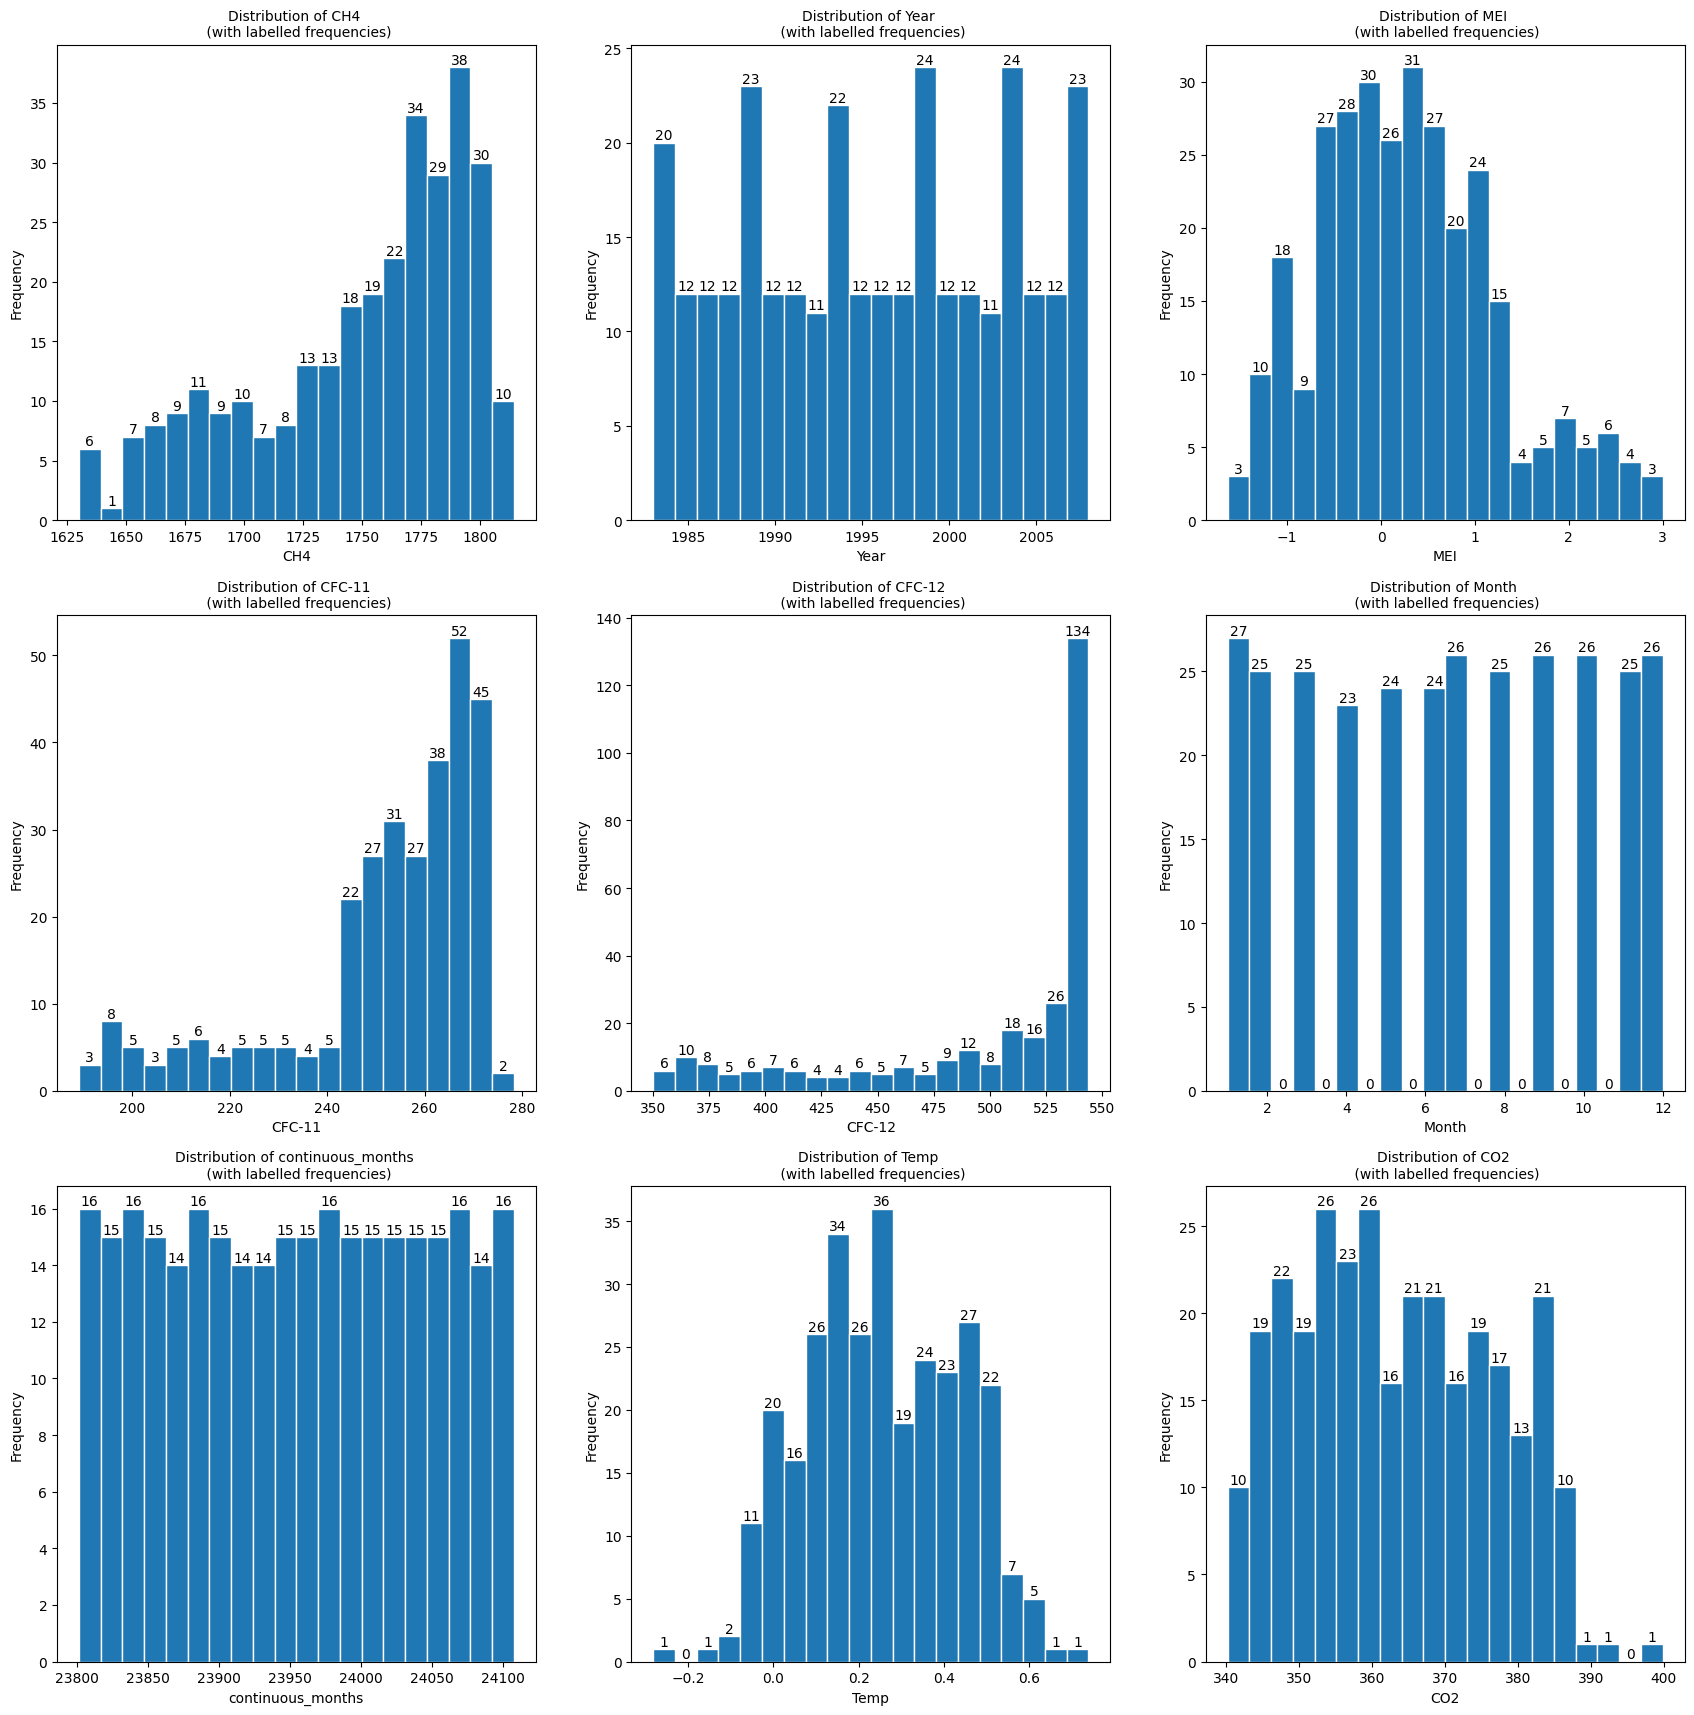

In [12]:
# function to plot data

def print_histogram(data,num_features):
    
    y = 1
    x = len(num_features)
    # calculate best integer to get a square grid
    while x > (y ** 2):
        y += 1
    
    # set graph layout parameters
    SCALE_FACTOR = 5 # size of each plot
    plot_h,plot_w = y,y # how many columns of plots

    # set figure dimensions and subplot layout
    fig,axes = plt.subplots(plot_h,plot_w,figsize=((SCALE_FACTOR+2)*plot_w,(SCALE_FACTOR+2)*plot_h))

    n = len(num_features)

    for i in range(n):
        feature = num_features[i]
        ax = plt.subplot(plot_h,plot_w,i+1)
        freq, bins, patches = ax.hist(data[feature],bins=20,edgecolor='white')
        bin_centers = np.diff(bins)*0.5 + bins[:-1]
        
        h = 0
        for fr, x, patch in zip(freq, bin_centers, patches):
            height = int(freq[h])
            ax.annotate("{}".format(height),
                        xy = (x, height),             # top left corner of the histogram bar
                        xytext = (0,0.2),             # offsetting label position above its bar
                        textcoords = "offset points", # Offset (in points) from the *xy* value
                        ha = 'center', va = 'bottom'
                        )
            h = h+1

        ax.set_title(f"Distribution of {feature} \n (with labelled frequencies)", fontsize=10)
        ax.set_xlabel(feature, fontsize=10)
        ax.set_ylabel("Frequency", fontsize=10)
    plt.show()

print_histogram(data,numerical_features)

<span style="color:LightSkyBlue">

Based on a visual observation we noted the following:
- The variable `Year`, `month` and `continuous_months` are either used to build (or can themselves operate as) an index for each row. However, it may be useful since the atmospheric temperature may be related to variables that aren't recorded in our dataset but change over time such as `<FIND REASON>`, thus making it significant. furthermore, `continuous_months` makes more sense to retain because it represents a continuous flow of time rather than the `Year` and `Month` variables, thus we will likely not select the latter two as features.
- Given that `CFC-11` and `CFC-12` are somewhat similar since they are both chloroflourocarbons, we could consider creating a new feature that groups them together in some way.
- `CFC-12` and `CFC-11` each are highly skewed values. We will likely need to perform a log transformation to mitigate the effect of its skewness. (to assess how significant doing this is, we will simply compare visually using a quartile-quartile plot of a normal distribution how significant this transformation is.)

### TODO: replace the `<FIND REASONS>` with meaningful research. I leave its complexity to your discretion. ps: reasoning for including Continuous_months kinda iffy, help justify if not remove

<span style="color:LightSkyBlue">

Thus, we will do the following for numerical feature selection:
1. Exclude the `Year` and `Month` variable from our selected features
2. Find a suitable combination of `CFC-12` and `CFC-11` and use that as a feature instead
3. Visualise the $r^2$ values of each pair of variables, and assess which are relevant to retain
4. Perform a log transformation to all skewed variables (`MEI`,`CH4`, and likely the new combined CFC feature.)

<span style="color:LightSkyBlue">

1.  remove the features `Year` and `Month` from our numerical features

In [13]:
# declare variables that are irrelevant
numerical_features = datatypes[datatypes!="object"].index
cat_encoded = {'Aerosols_ord', 'N2O_ord', 'TSI_ord'}
numerical_features = list(set(numerical_features) - cat_encoded)
num_irrelevant = {'Year','Month'}
numerical_features = list(set(numerical_features) - num_irrelevant)

<span style="color:LightSkyBlue">

2. Create variations of combining `CFC-11` and `CFC-12`, naming the variable `CFC_<op>` based on the operation performed.

In [14]:
# new feature: CFC_add = "CFC-11" + "CFC-12"
if 'CFC_add' not in numerical_features:
    data['CFC_add'] = data['CFC-12'] + data['CFC-11']
    numerical_features.append('CFC_add')

#new feature: CFC_times = "CFC-11" * "CFC-12"
if 'CFC_times' not in numerical_features:
    data['CFC_times'] = data['CFC-11'] * data['CFC-12']
    numerical_features.append('CFC_times')
    
# if cell was run multiple times, this line makes sure there are no duplicates
data.loc[:,~data.columns.duplicated()]
print(f"we are now handling the following {len(numerical_features)} numerical features:")
print(numerical_features)

we are now handling the following 9 numerical features:
['CH4', 'MEI', 'CFC-11', 'CFC-12', 'continuous_months', 'Temp', 'CO2', 'CFC_add', 'CFC_times']


In [15]:
print(numerical_features)

['CH4', 'MEI', 'CFC-11', 'CFC-12', 'continuous_months', 'Temp', 'CO2', 'CFC_add', 'CFC_times']


<span style="color:LightSkyBlue">

we can visualise this new set of features using the `print_historgram` function from above:

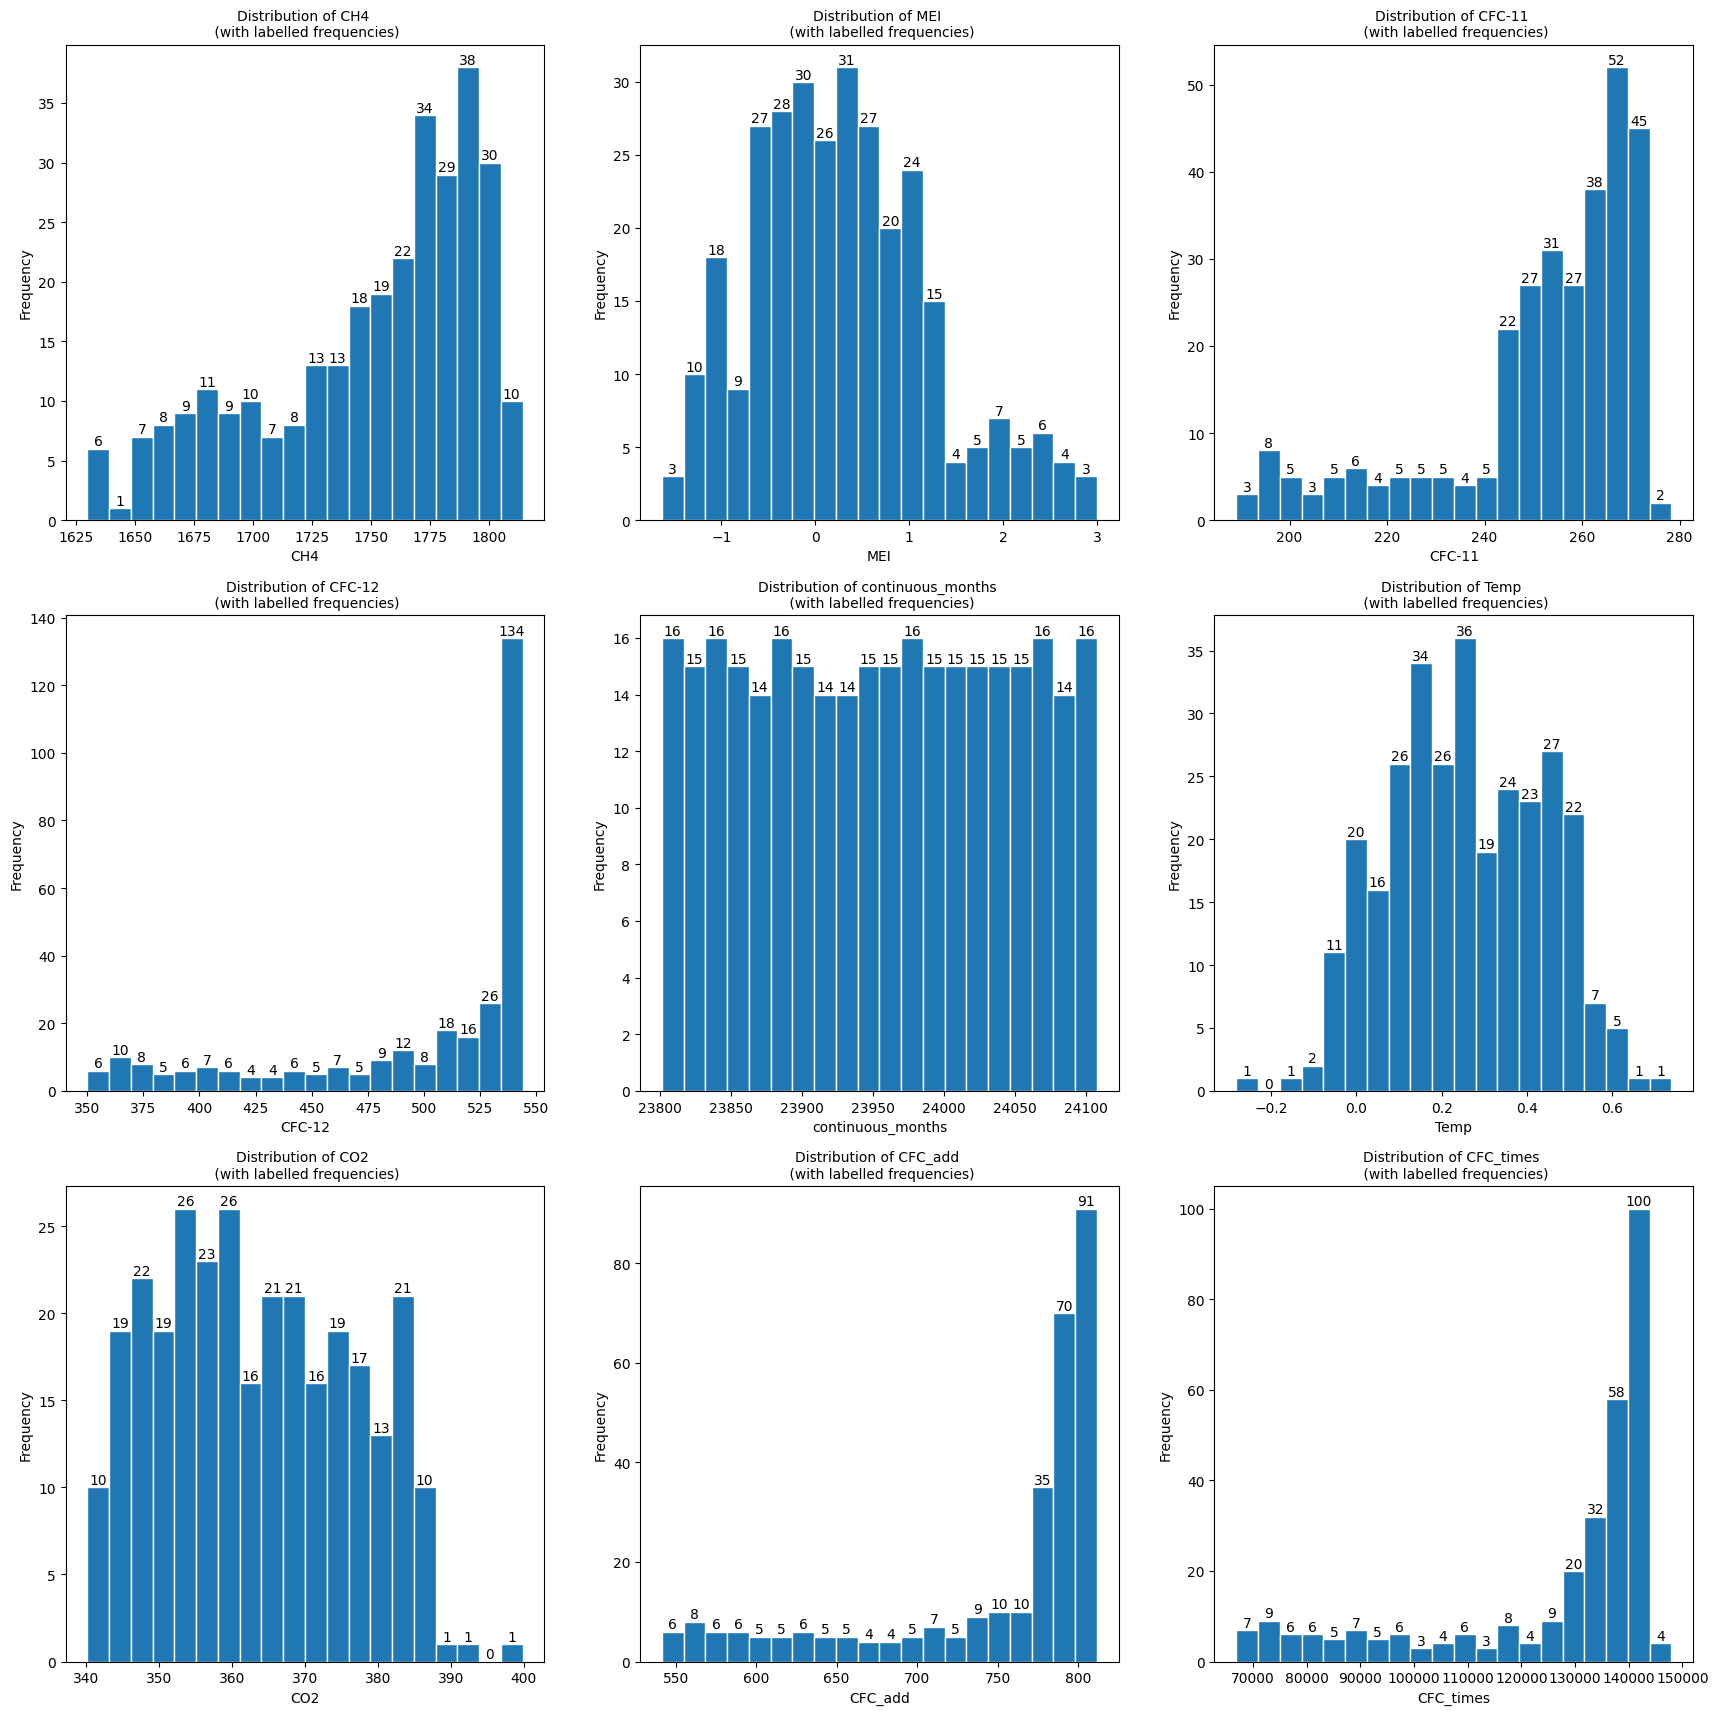

In [16]:
print_histogram(data,numerical_features)

<span style="color:LightSkyBlue">

As many of the features (namely, `MEI`,`CH4`, `CFC-11`, `CFC-12`, `CFC_add` and `CFC_times`) are highly skewed, we can use either:
- a power transformer and perform the yeo-johnson transformation to apply non-linear transformations to enable our data to better resemble a normal distribution;
- a quantile transformer, which will provide non-linear transformations to 

In [17]:
from sklearn.preprocessing import QuantileTransformer

#ensure duplicate rows are not created from running this cell multiple times
data.loc[:,~data.columns.duplicated()]

qt = QuantileTransformer(output_distribution='normal', random_state=42,n_quantiles=302)

data['CFC_add_norm'] = qt.fit_transform(data[['CFC_add']])
data['CFC_times_norm'] = qt.fit_transform(data[['CFC_times']])
data['CFC_11_norm'] = qt.fit_transform(data[['CFC-11']])
data['CFC_12_norm'] = qt.fit_transform(data[['CFC-12']])
data['CH4_norm'] = qt.fit_transform(data[['CH4']])
data['MEI_norm'] = qt.fit_transform(data[['MEI']])

numerical_features = numerical_features + [
    'CFC_add_norm',
'CFC_times_norm',
'CFC_11_norm',
'CFC_12_norm',
'CH4_norm',
'MEI_norm'
]

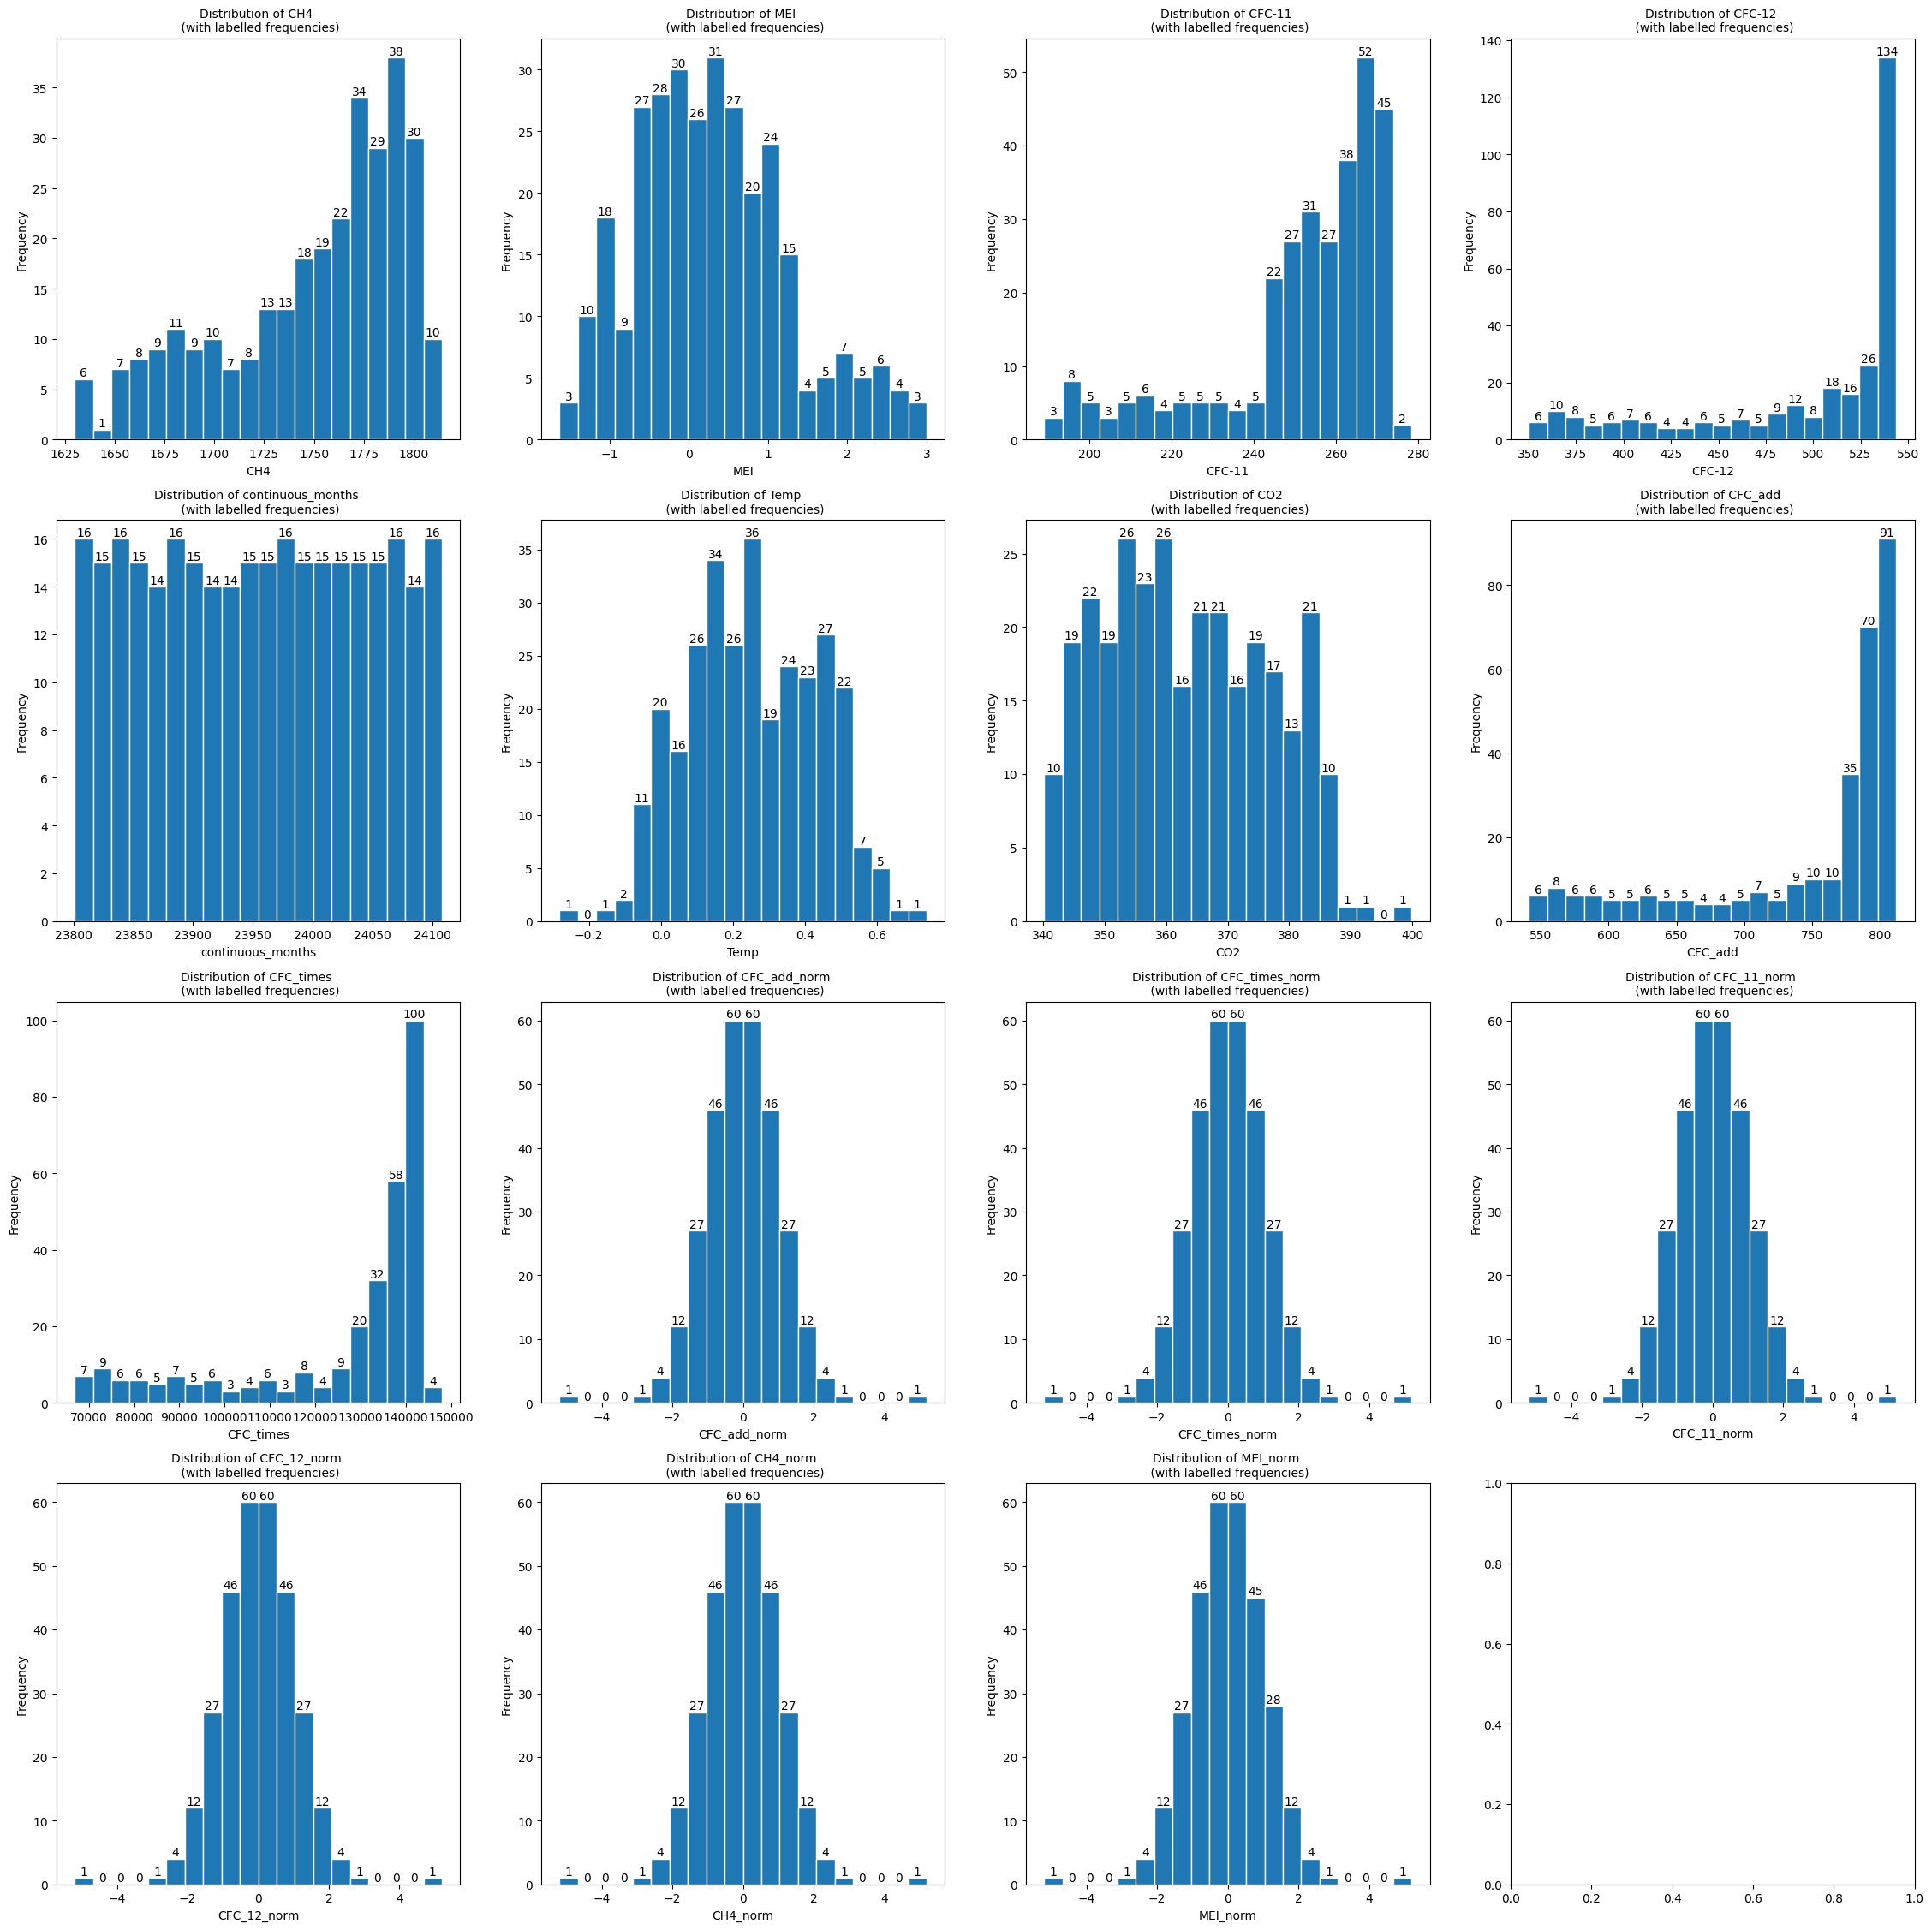

In [18]:
print_histogram(data,numerical_features)

<span style="color:LightSkyBlue">

Next, we can assess a heat map of the correlation values of this new set of features.

In [19]:
# use standardised temp
from sklearn.preprocessing import StandardScaler
data['Temp_st'] = StandardScaler().fit_transform(data[['Temp']])
data.loc[:,~data.columns.duplicated()]

numerical_features.append('Temp_st') if 'Temp_st' not in numerical_features else numerical_features
numerical_features.remove('Temp')

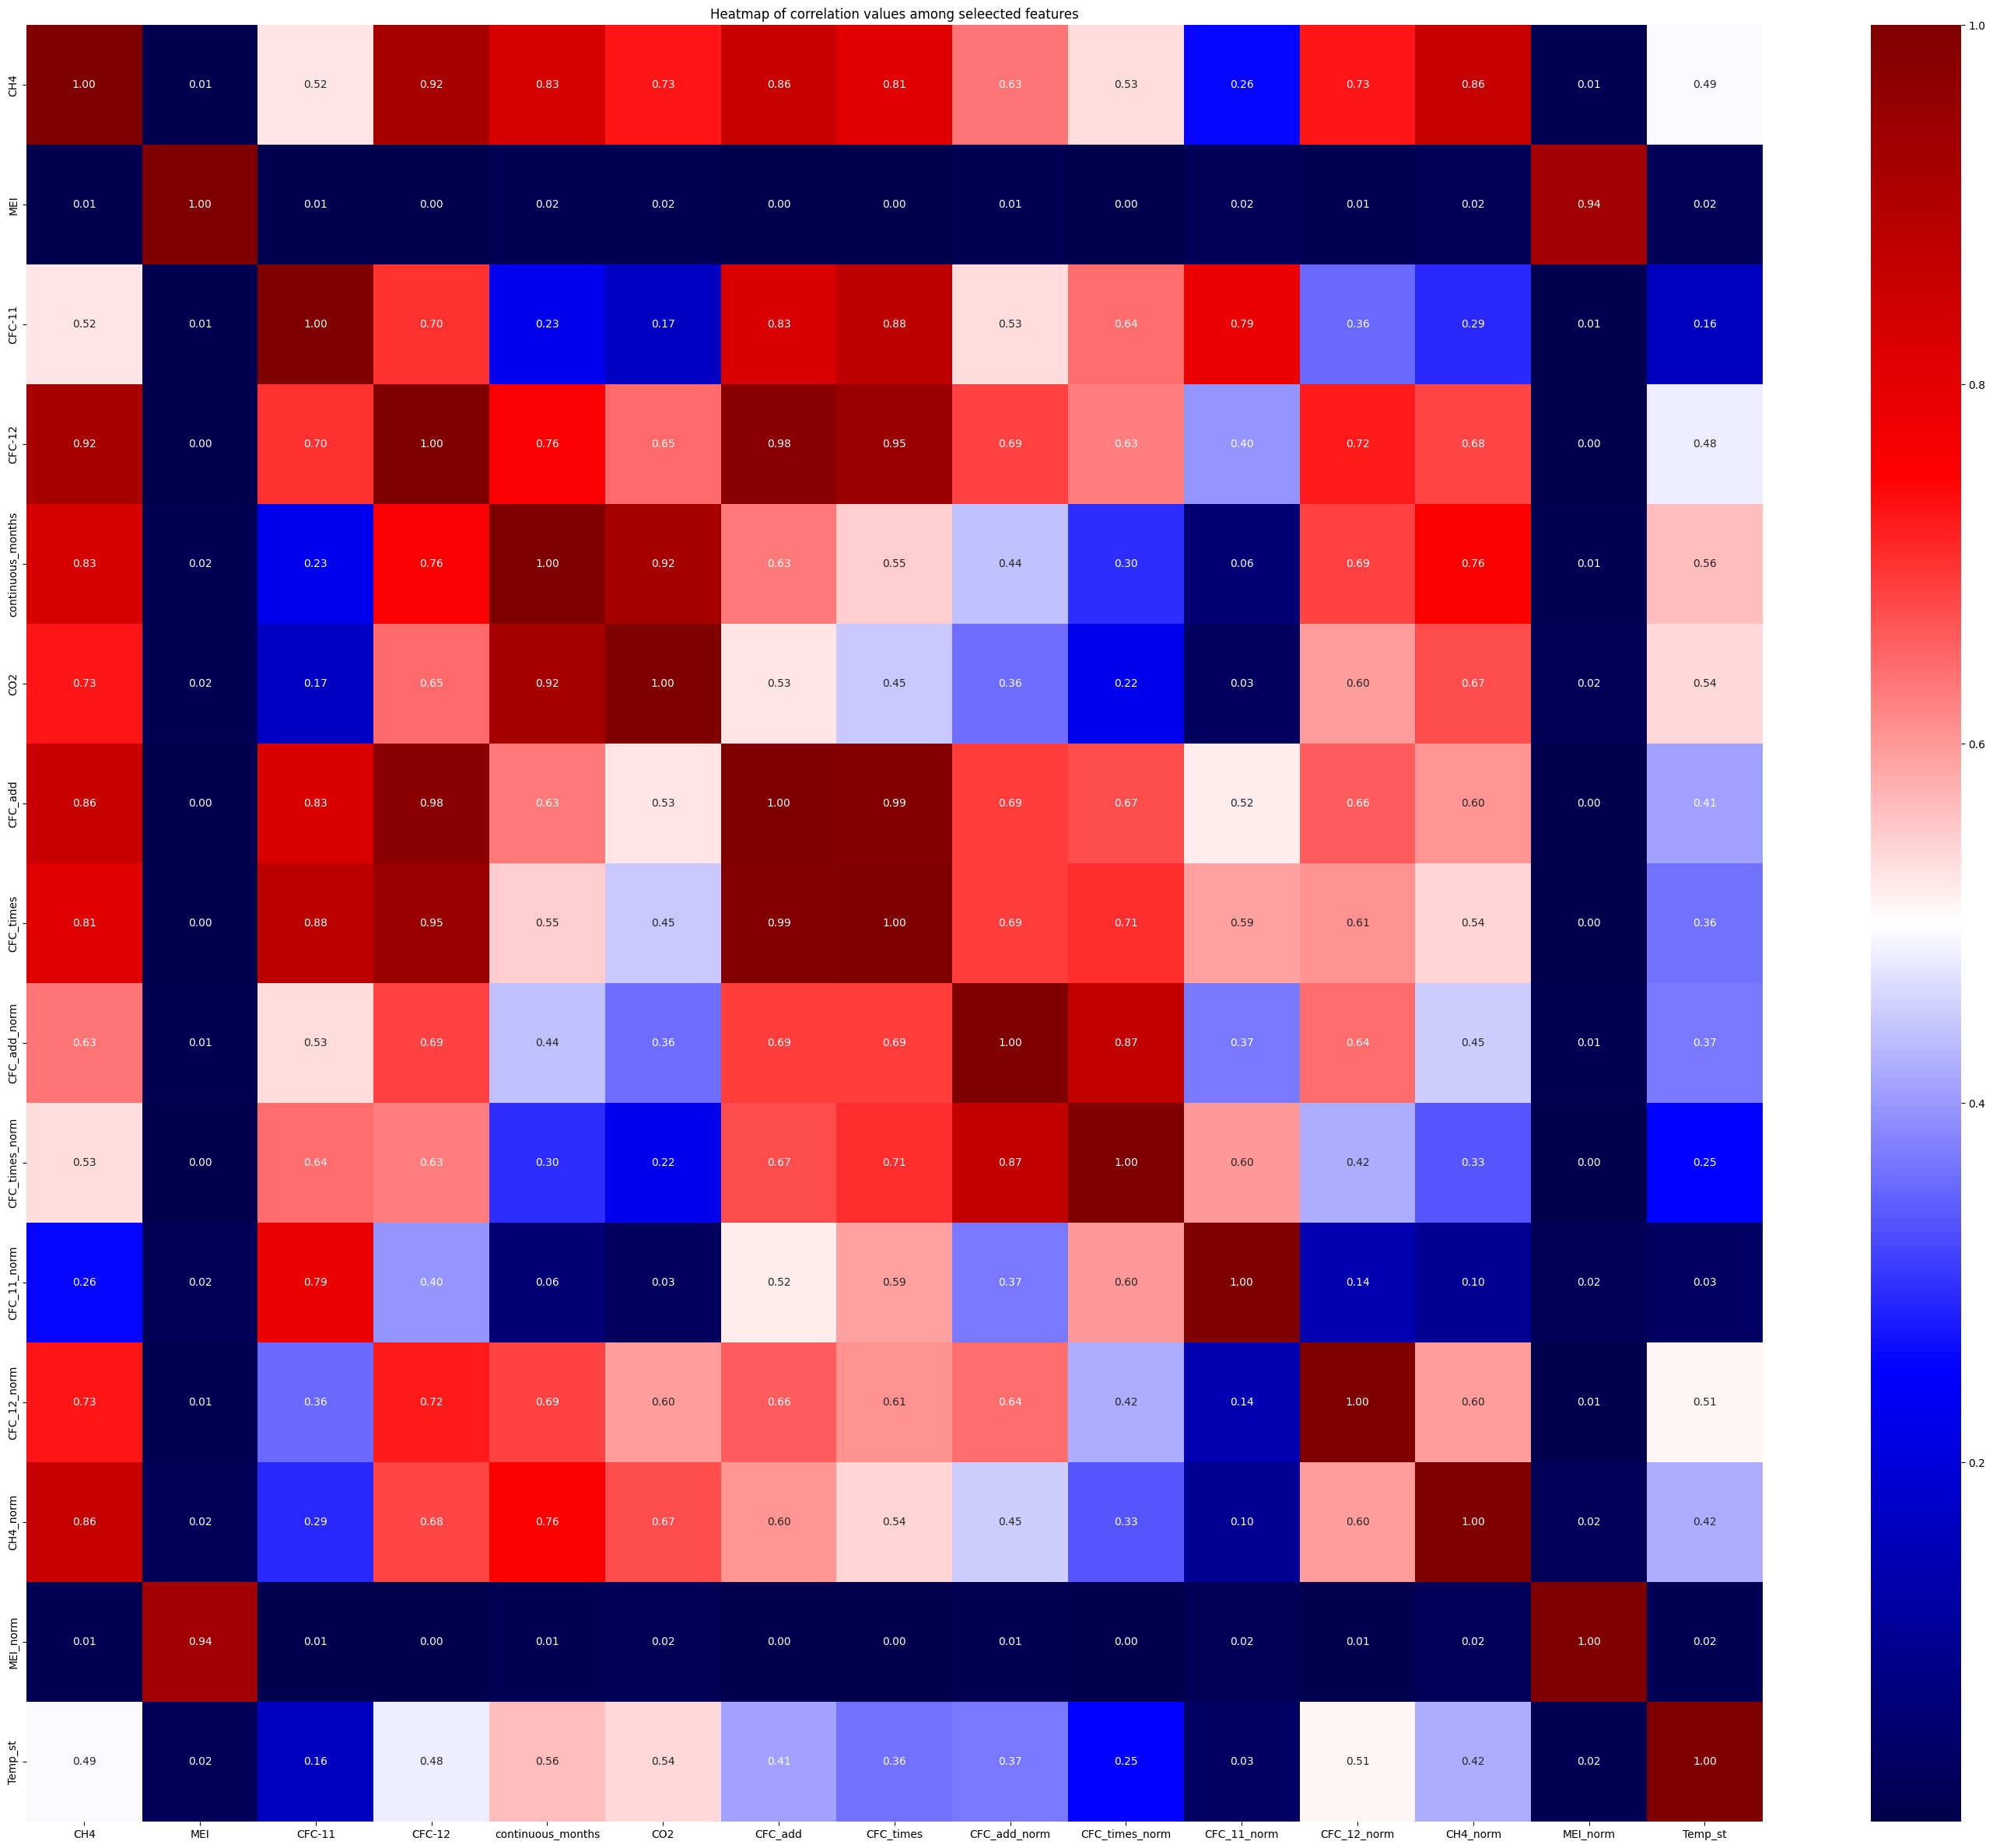

In [20]:
import seaborn as sns
datatset_correlations = data[numerical_features].corr()
r2 = data[numerical_features].corr()**2
plt.figure(figsize=(36, 30))
sns.heatmap(r2, annot=True, fmt='.2f', cmap='seismic')
plt.title('Heatmap of correlation values among seleected features')
plt.show()

<span style="color:LightSkyBlue">

Before we perform a log transformation of our data, we will prematurely assess whether the dependent variable `Temp` is correlated with our independent variables. We could do it with a correlation table or via correlation heatmap as above.  As prescribed in lab3, we have plot our correlation heatmap using the $r^2$ values instead, where the closer each value is to 0, the more 'blue' a cell will be and the less related each value will be. 

3. Referencing the above heatmap, we will be pruning these highly-uncorrelated features. However, we will lower the threshold than what was prescribed in lab3 as most of the features have $r^2$ values that hover slightly below the 0.5 threshold, thus we will change it to 0.45.

In [21]:

def corr_features(df, target, threshold):
    corr_features = []
    for feature in df.columns:
        if feature==target: continue
        x = df[feature]
        y = df[target]
        r2 = np.corrcoef(x,y)[0][1]
        if abs(r2)>threshold:
            corr_features.append(feature)
    return corr_features

numerical_features_selected = corr_features(data[numerical_features], 'Temp_st', 0.5)
print(f"updated selected features: {numerical_features_selected}")

updated selected features: ['CH4', 'CFC-12', 'continuous_months', 'CO2', 'CFC_add', 'CFC_times', 'CFC_add_norm', 'CFC_times_norm', 'CFC_12_norm', 'CH4_norm']


<span style="color:LightSkyBlue">

We will also remove any features that are too correlated to each other, since it means that we can further reduce the number of dimensions that our data has. This renders the following benefits: 
- Our model performance will likely be higher
- Model training and inference will be faster since less data is involved
- The model has a lower chance of overfitting

However, removing too many features may have the opposite effect of making our model less accurate, thus we will retain at least 3 features, and set our threshold $r^2$ value for removing features to be 0.9.

<span style="color:LightSkyBlue">

First, lets visualise the correlation map of currently selected features:

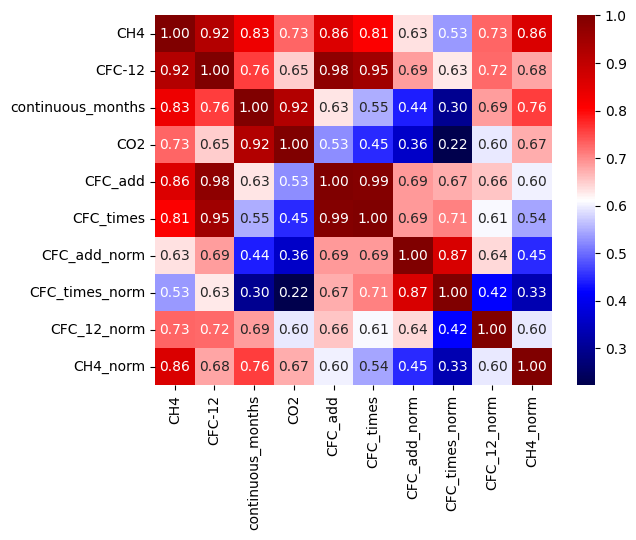

In [22]:
r2_predictors = data[numerical_features_selected].corr()**2
sns.heatmap(r2_predictors, annot=True, fmt='.2f', cmap='seismic')
plt.show()

<span style="color:LightSkyBlue">

Next, lets remove the highly correlated features. 

In [23]:
# get the feature that has the most number of features
# it is correlated with, beyond certain threshold

def most_corr_feature(df, threshold):
    r2_matrix = abs(df.corr()**2)
    count = r2_matrix[r2_matrix>threshold].count()
    return count.sort_values(ascending=False).index[0]

# return true if all the features are uncorrelated,
# as defined by a threshold

def all_features_uncorr(df, threshold):
    r2_matrix = abs(df.corr()**2)
    n = len(r2_matrix)
    
    # checks for any pair of variables with r^2 value higher than threshold
    return r2_matrix[r2_matrix>threshold].count().sum()==n

# get a set of uncorrelated features
def get_uncorr_features(df, threshold,min_features=0):
    features = df.columns.tolist()
    while all_features_uncorr(df[features], threshold) == False and len(features)> min_features:
        most_corr_fea = most_corr_feature(df[features], threshold)
        features.remove(most_corr_fea)
    return features

In [24]:
numerical_features_selectedV2 =[i for i in numerical_features_selected if i != 'Temp']

numerical_features_selectedV2 = get_uncorr_features(data[numerical_features_selectedV2], 0.8,min_features=0)
print(f"Selected numerical features : {numerical_features_selectedV2}")

Selected numerical features : ['CO2', 'CFC_times', 'CFC_add_norm', 'CFC_12_norm', 'CH4_norm']


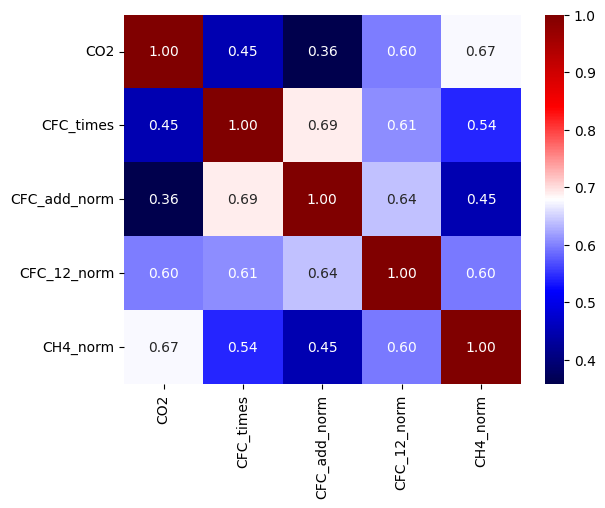

In [25]:
numerical_features_selected = numerical_features_selectedV2.copy()
r2_predictors = data[numerical_features_selected].corr()**2
sns.heatmap(r2_predictors, annot=True, fmt='.2f', cmap='seismic')
plt.show()

<span style="color:LightSkyBlue">

4. Lastly, we will transform the features that do not look like any typical distributions (ie. the normal distribution). We will save variations of these sets of transformed features and see if the transformed data will yield better predictions when we create our model later.

<span style="color:LightSkyBlue">
First, we will visualise the selected features thus far:

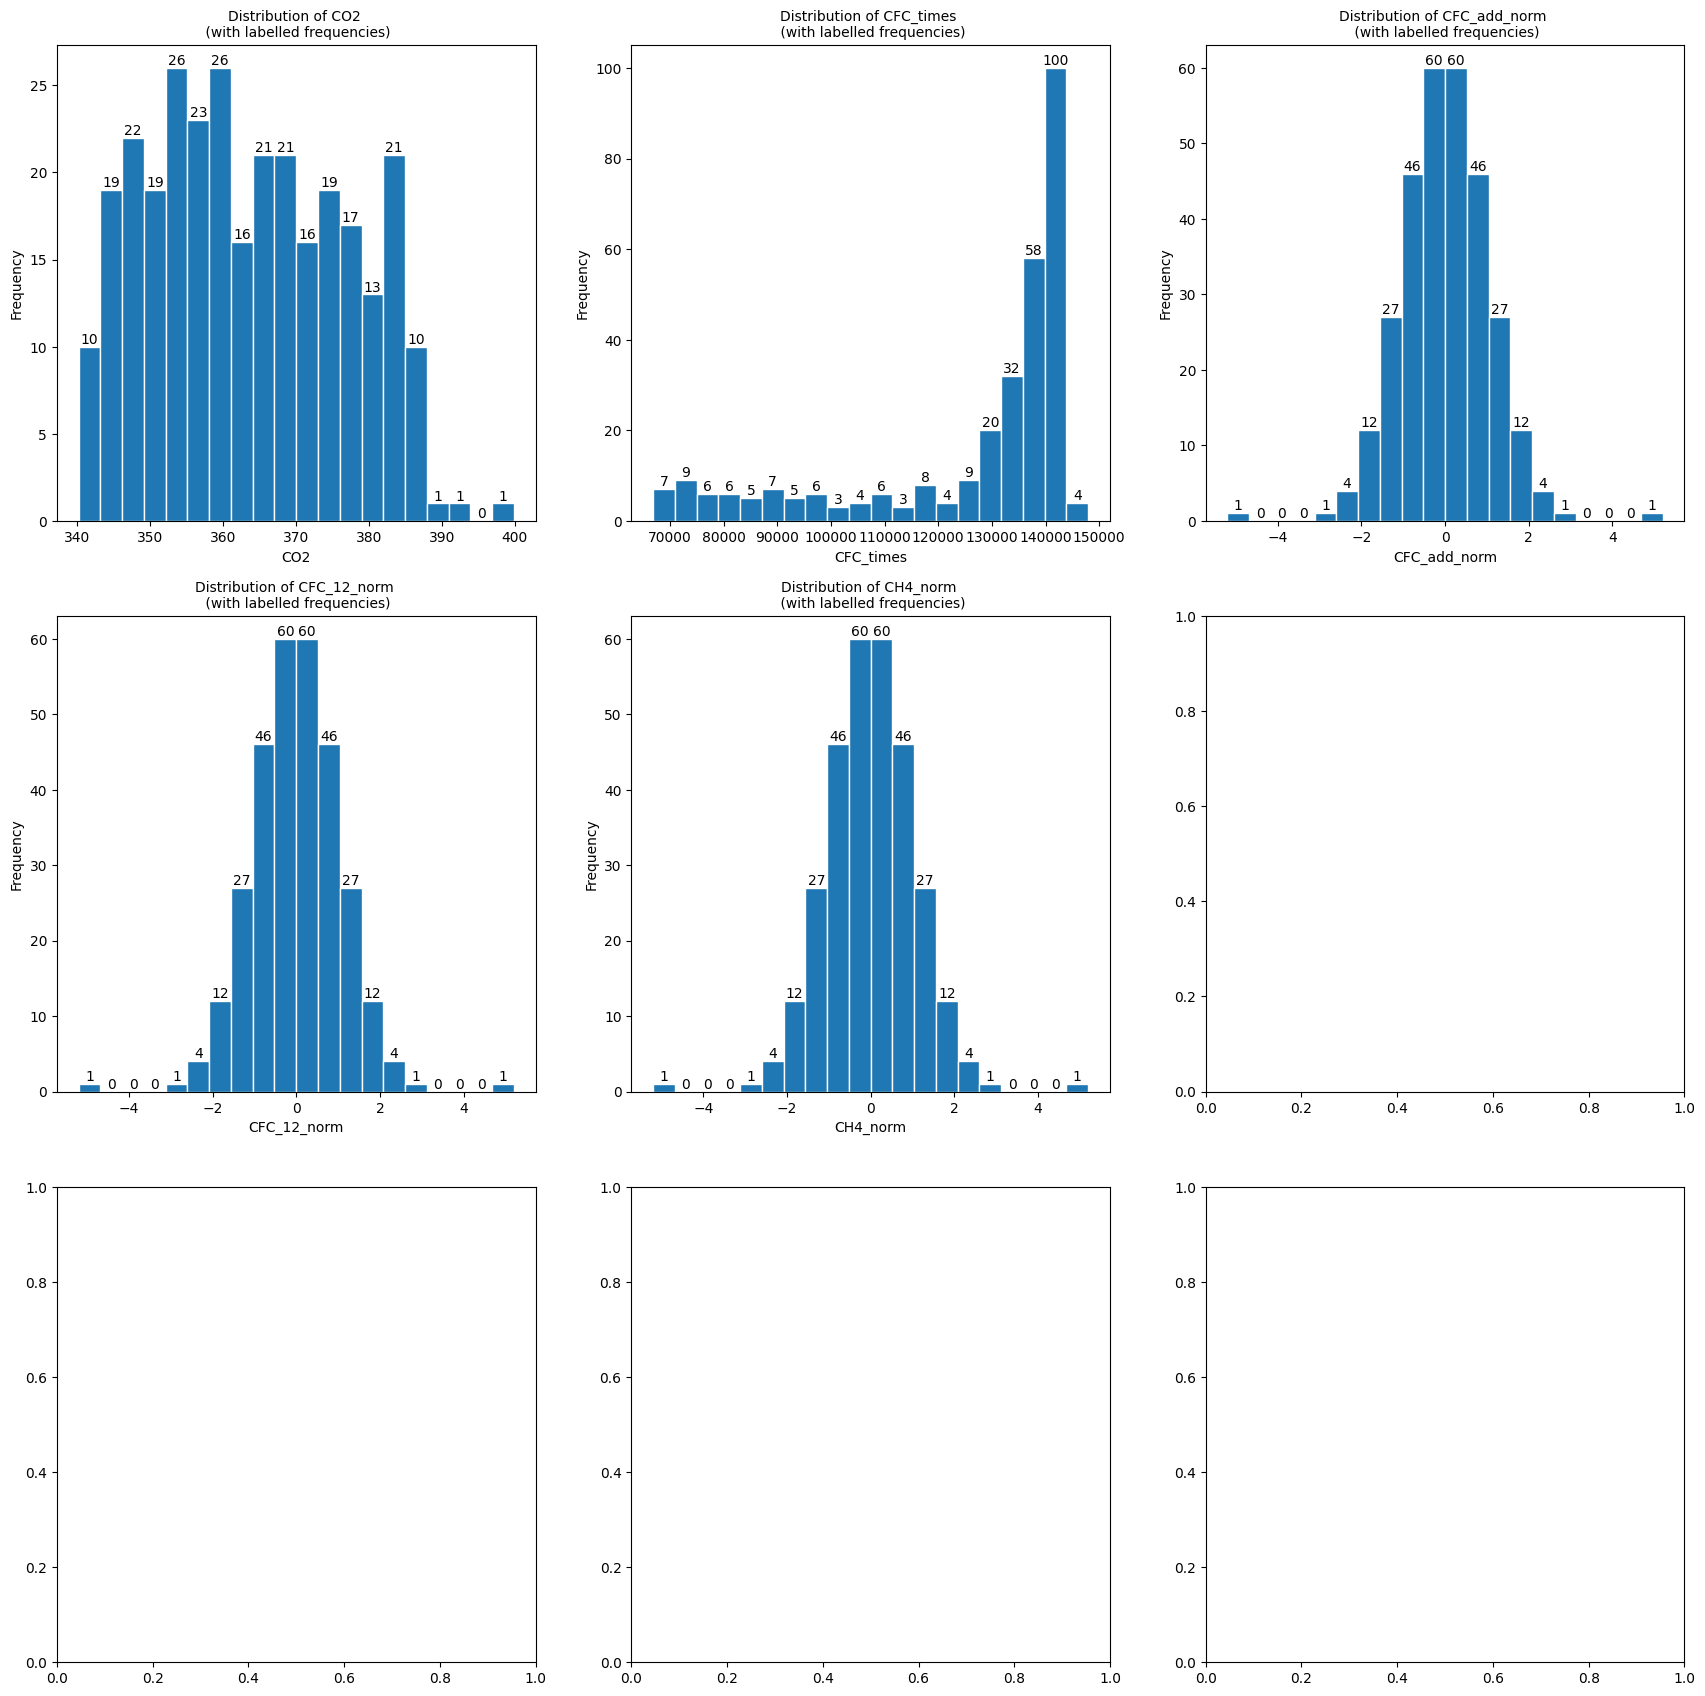

In [26]:
print_histogram(data,numerical_features_selected)

In [27]:
numerical_features_selected = list(set(numerical_features_selected) - {'Temp'})
print(numerical_features_selected)

['CFC_times', 'CFC_add_norm', 'CH4_norm', 'CO2', 'CFC_12_norm']


In [28]:
# tf1 -- transform CH4 to log scale
numerical_features_selected_tf1 = numerical_features_selected.copy()
data['CFC_times_lg'] = np.log(data['CFC_times'])

numerical_features_selected_tf1.append('CFC_times_lg')
numerical_features_selected_tf1.remove('CFC_times')

# tf1 -- transform CH4 to log scale
from sklearn.preprocessing import StandardScaler

numerical_features_selected_tf2 = numerical_features_selected.copy()
data['CFC_times_lg'] = np.log(data['CFC_times'])
data['CFC_times_lg_st'] = StandardScaler().fit_transform(data[['CFC_times_lg']])

numerical_features_selected_tf2.append('CFC_times_lg_st')
numerical_features_selected_tf2.remove('CFC_times')


#ensure no duplicate rows exist from multiple runs of this cell
data.loc[:,~data.columns.duplicated()]

,Year,Month,MEI,CO2,CH4,N2O,CFC-11,CFC-12,TSI,Aerosols,...,CFC_times,CFC_add_norm,CFC_times_norm,CFC_11_norm,CFC_12_norm,CH4_norm,MEI_norm,Temp_st,CFC_times_lg,CFC_times_lg_st
0,1983,5.0,2.556,345.96,1638.59,L,191.324,350.113,M,H,...,66985.019612,-5.199338,-2.714154,-2.714154,-5.199338,-2.129383,2.055123,-0.832828,11.112224,-2.965052
1,1983,6.0,2.167,345.52,1633.71,L,192.057,351.848,M,H,...,67574.871336,-2.475928,-2.475928,-2.475928,-2.714154,-2.327596,1.646466,-0.782381,11.120991,-2.922758
2,1983,7.0,1.741,344.15,1633.22,L,189.051,353.725,M,H,...,66872.064975,-2.714154,-5.199338,-5.199338,-2.475928,-2.475928,1.342599,-0.675880,11.110537,-2.973194
3,1983,8.0,1.130,342.25,1631.35,L,193.602,355.633,M,H,...,68851.260066,-2.327596,-2.327596,-2.327596,-2.327596,-2.714154,0.983053,-0.457275,11.139704,-2.832486
4,1983,9.0,0.428,340.17,1648.40,L,194.392,357.465,M,H,...,69488.336280,-2.217659,-2.217659,-2.217659,-2.217659,-1.990720,0.239612,-0.608617,11.148914,-2.788053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,2008,8.0,-0.266,384.15,1779.88,L,244.200,535.072,L,L,...,130664.582400,-0.300075,-0.452147,-0.832165,0.196966,0.433775,-0.517724,0.837542,11.780389,0.258302
298,2008,9.0,-0.643,383.09,1795.08,L,244.083,535.048,L,M,...,130596.120984,-0.313168,-0.470674,-0.843997,0.188483,1.082411,-1.052961,0.674990,11.779865,0.255774
299,2008,10.0,-0.780,382.99,1814.18,L,244.080,534.927,L,M,...,130564.982160,-0.335111,-0.489363,-0.855948,0.163110,5.199338,-1.210952,1.022516,11.779626,0.254623
300,2008,11.0,1.345,384.13,1812.37,L,244.225,534.906,L,M,...,130637.417850,-0.313168,-0.461391,-0.820449,0.154676,2.475928,1.210952,0.764674,11.780181,0.257299


3 versions of our features have been made:
- `numerical_features_selected` --- The untransformed features that have met our criteria for correlation values 
- `numerical_features_selected_tf1` --- `CFC_add` was log-transformed and renamed `CFC_add_lg`
- `numerical_features_selected_tf2` --- `CH4` was log-transformed and renamed `CH4_lg`
- `numerical_features_selected_tf3` --- `CFC_add` was transformed to resemble a normal distribution using Scikit learn's `quantile transformer` function, and renamed `CFC_add_norm`.

<span style="color:LightSkyBlue">

# TODO: Wei Bin i have no idea how to fit this in, please help

Based on the correlation analysis and heatmap visualization, I have selected the following numerical variables for predicting temperature:

**Primary Features (Strong Correlations):**
1. CO2 (correlation = 0.71)
   - Strongest correlation with temperature among all variables
   - Key greenhouse gas with direct physical relationship to global warming
   - Shows consistent positive trend with temperature

2. CH4 (correlation = 0.69)
   - Strong positive correlation with temperature
   - Known potent greenhouse gas (28 times more potent than CO2)
   - Provides complementary information to CO2

3. CFC-12 (correlation = 0.69)
   - Strong correlation with temperature
   - Class 1 Ozone-depleting substance with high global warming potential
   - Important atmospheric indicator

**Features Excluded:**

1. CFC-11 (correlation = 0.66)
   - Despite moderate correlation with temperature, excluded due to very high multicollinearity with CFC-12 (0.98)
   - Including both CFC-11 and CFC-12 would introduce redundancy in the model
   - CFC-12 preferred due to its higher global warming potential

2. MEI (correlation = 0.14)
   - Very weak correlation with temperature
   - While it measures important climate phenomena (El Niño/La Niña), the low correlation suggests limited direct predictive value for temperature


**Justification:**
- Selection prioritizes variables with correlation coefficients > 0.65 with temperature
- Avoids multicollinearity by not including highly correlated predictor pairs
- Chosen variables have clear physical mechanisms linking them to temperature changes
- Selected features represent different aspects of atmospheric composition affecting global temperature

<span style="color:LightSkyBlue">

# TODO: Wei Bin i have no idea how to fit this in, please help

### Removal of selected features that are correlated to each other

Looking at the correlation heatmap:

CO2 with CH4: correlation = 0.94  
CO2 with CFC-12: correlation = 0.96  
CH4 with CFC-12: correlation = 0.91  

This reveals a significant issue: all three of our selected features are highly correlated with each other (correlation coefficients > 0.90). This indicates strong multicollinearity, which means these variables are indeed redundant with each other.
Given this high multicollinearity, we should revise our feature selection. Here's how we should proceed:
Since CO2 has the highest correlation with temperature (0.71), we should keep it as our primary feature.
We should exclude CH4 and CFC-12 despite their strong correlations with temperature because:
They are highly correlated with CO2 (0.94 and 0.96 respectively)
Including them would introduce redundancy in our model

Their relationships with temperature might be captured indirectly through CO2

lastly, we will combine the features that we have selected from the pool of categorical and numerical variables.

In [29]:
features_selected = cat_features_selected + numerical_features_selected_tf2
print(", ".join(features_selected))

TSI_ord, Aerosols_ord, CFC_add_norm, CH4_norm, CO2, CFC_12_norm, CFC_times_lg_st


**b.** Split the dataset into train and test sets. Describe how you split step by step.

**Response.** 

We will use the prescribed method from lab3, and split the data using the function under the sci-kit learn library `train_test_split` for splitting our data. We will also be performing an 80-20 test-train split as prescribed for many model training techniques.

In [30]:
from sklearn.model_selection import train_test_split

#features_selected = ['Aerosols_ord' ,'CO2','CFC-11' ,'CFC-12']
X = data[features_selected]
y = data[["Temp_st"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

**c.** State the model(s) you will train, and explain your choice(s), in **no more than 50 words per model**. You only need to
train one model, but if you do train more models, limit yourself to no more than three---Grading is based on the validity and soundness of your model, rather than the quantity.

**Response.** 

**Models Selected:**

1. Linear regression
2. Elastic Net Regression with Cross validation
3. 



**d.** For each model, perform the training, and report the trained parameters and the training scores, if applicable. 

**Response.** 

In [31]:
## model fitting for linear regression

from sklearn.linear_model import LinearRegression

model1 = LinearRegression().fit(X_train, y_train)
model1_r2 = model1.score(X_train, y_train)
model1_r2_val = model1.score(X_test, y_test)
coef1 = model1.coef_
bias1 = model1.intercept_

print("Model 1: Linear Regression ")
print("--------------------------")
print(f"Features : {X_train.columns.tolist()}")
print(f"Coefficients: {coef1[0]}")
print(f"Intercept : {bias1[0]}")
print(f"Coeff of Determination : {model1_r2}")
print(f"Coeff of Determination (on validation set): {model1_r2_val}")

Model 1: Linear Regression 
--------------------------
Features : ['TSI_ord', 'Aerosols_ord', 'CFC_add_norm', 'CH4_norm', 'CO2', 'CFC_12_norm', 'CFC_times_lg_st']
Coefficients: [ 0.20748353 -0.26922705 -0.255703   -0.01986658  0.02594094  0.35882216
  0.12592965]
Intercept : -9.391729324311047
Coeff of Determination : 0.6602953992385064
Coeff of Determination (on validation set): 0.5777173079478544


In [32]:
## model fitting for ridge
from sklearn.kernel_ridge import KernelRidge

model15 = KernelRidge().fit(X_train, y_train)
model15_r2 = model15.score(X_train, y_train)
model15_r2_val = model15.score(X_test, y_test)
#coef2 = model15.coef_
#bias2 = model15.intercept_
print(bias2)

print("Model 2: Ridge Regression")
print("-------------------------")
print(f"Features : {X_train.columns.tolist()}")
print(f"Coefficients: {coef2[0]}")
print(f"Intercept : {bias2}")
#print(f"Intercept : {bias2[0]}")
print(f"Coeff of Determination : {model15_r2}")
print(f"Coeff of Determination (on validation set): {model2_r2_val}")

NameError: name 'bias2' is not defined

In [ ]:
## model fitting for ridge

from sklearn.ensemble import GradientBoostingRegressor

model2 = GradientBoostingRegressor().fit(X_train, y_train)
model2_r2 = model2.score(X_train, y_train)
model2_r2_val = model2.score(X_test, y_test)
#coef2 = model2.coef_
#bias2 = model2.intercept_
#print(bias2)

print("Model 2: Ridge Regression")
print("-------------------------")
print(f"Features : {X_train.columns.tolist()}")
#print(f"Coefficients: {coef2[0]}")
#print(f"Intercept : {bias2}")
#print(f"Intercept : {bias2[0]}")
print(f"Coeff of Determination : {model2_r2}")
print(f"Coeff of Determination (on validation set): {model2_r2_val}")

Model 2: Ridge Regression
-------------------------
Features : ['TSI_ord', 'Aerosols_ord', 'CH4_norm', 'CFC_12_norm', 'CFC_add_norm', 'CO2', 'CFC_times_lg_st']
Coeff of Determination : 0.996279310271503
Coeff of Determination (on validation set): 0.6854123951437334


c:\Users\ChunChunMaru\anaconda3\envs\QNN\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [ ]:
## model fitting for ridge
from sklearn.svm import LinearSVR

model3 = LinearSVR().fit(X_train, y_train)
model3_r2 = model3.score(X_train, y_train)
model3_r2_val = model3.score(X_test, y_test)
coef3 = model3.coef_
bias3 = model3.intercept_

print("Model 2: Ridge Regression")
print("-------------------------")
print(f"Features : {X_train.columns.tolist()}")
print(f"Coefficients: {coef3}")
#print(f"Coefficients: {coef3[0]}")
print(f"Intercept : {bias3[0]}")
print(f"Coeff of Determination : {model3_r2}")
print(f"Coeff of Determination (on validation dataset): {model3_r2}")

Model 2: Ridge Regression
-------------------------
Features : ['TSI_ord', 'Aerosols_ord', 'CH4_norm', 'CFC_12_norm', 'CFC_add_norm', 'CO2', 'CFC_times_lg_st']
Coefficients: [ 0.03328271 -0.09200126  0.14451021  0.15302778  0.09209005  0.00102664
  0.10221667]
Intercept : -0.00548969804714624
Coeff of Determination : 0.4115646426120311
Coeff of Determination (on validation dataset): 0.4115646426120311


c:\Users\ChunChunMaru\anaconda3\envs\QNN\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ChunChunMaru\anaconda3\envs\QNN\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### 3. Model evaluation and selection [30% of Part II]

**a.** For each model, predict the response variable on the test set.

**Response.** 

In [ ]:
## model 1 evaluation

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

# predict based on test set
y_pred = model1.predict(X_test)

# compare with ground truth
mae = mean_absolute_error(y_test, y_pred)
ave = np.mean(y_test["Temp"])
rmse = root_mean_squared_error(y_test, y_pred)  # setting squared = False returns the square-root 




print("Model 1 Evaluation")
print("-----------------")
print(f"MAE: {mae:.2f}")
print(f"MAE as % of mean: {mae/ave*100:.1f}%")
print(f"RMSE: {rmse:.2f}")
print(f"RMSE as % of mean: {rmse/ave*100:.1f}%")

Model 1 Evaluation
-----------------
MAE: 0.09
MAE as % of mean: 34.9%
RMSE: 0.12
RMSE as % of mean: 46.7%


In [ ]:
## model 2 evaluation

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

# predict based on test set
y_pred2 = model2.predict(X_test)

# compare with ground truth
mae2 = mean_absolute_error(y_test, y_pred2)
ave = np.mean(y_test["Temp"])
rmse2 = root_mean_squared_error(y_test, y_pred2)  # setting squared = False returns the square-root 

print("Model 2 Evaluation")
print("-----------------")
print(f"MAE: {mae2:.2f}")
print(f"MAE as % of mean: {mae2/ave*100:.1f}%")
print(f"RMSE: {rmse2:.2f}")
print(f"RMSE as % of mean: {rmse2/ave*100:.1f}%")

Model 2 Evaluation
-----------------
MAE: 0.08
MAE as % of mean: 30.5%
RMSE: 0.10
RMSE as % of mean: 40.4%


**b.** Describe the metric you use to evaluate your model(s). Report the test scores for each model.

**Response.** 

**c.** If you trained more than one model, identify the final model you would choose for the prediction task, and explain your choice, **in no more than 50 words**.

**Response.** 

### 4. Findings and conclusion [20% of Part II]

**a.** Interpret what your model is implying, and summarize any insight you have drawn from the project. Explain if it is consistent with intuition, and if not, provide a plausible justification. Limit your entire response to **50 words**.

**Response.** 

**b.** Share any lesson you have learned from the project, in **no more than 50 words**.

**Response.** 

### 5. Non-technical protocol [5% of Part II]

**a.** Describe the detailed contribution of each team member, including both the tangible (e.g., implementation, testing, writing) and intangible (e.g., generating ideas, planning, leadership) efforts.

**Response.** 

**b.** List any references and sources you have cited.

**Response.** 